# Chapter 14: Ensemble Methods Assessment

## Assignment Overview

**Business Context**: You're a data analyst working for a financial services company. Your manager wants you to build **ensemble classification models** to predict whether credit card transactions are fraudulent. This is a **binary classification** task where you need to classify transactions as either "Fraud" (1) or "No Fraud" (0) based on transaction characteristics, customer demographics, and merchant information.

**Learning Objectives**:
- Understand how ensemble methods combine multiple models to improve predictions
- Build and evaluate bagging classifiers
- Build and evaluate random forest classifiers
- Build and evaluate boosting classifiers (AdaBoost, Gradient Boosting, XGBoost)
- Build and evaluate stacking classifiers
- Compare ensemble methods to single baseline models
- Interpret feature importance from ensemble models
- Understand when to use different ensemble methods

**Important Notes**:
- This assignment focuses on **Chapter 14 content only** (ensemble methods)
- You **WILL** split data into train/test sets (essential for evaluation)
- The goal is **predictive classification accuracy** and **probability quality** (log loss)
- Use sklearn pipelines to prevent data leakage
- Use `random_state=27` for all models that accept it (for reproducibility)

---

## Dataset Information

**Source**: Credit Card Fraud Detection Dataset  
**Description**:  
This dataset contains information about credit card transactions, including transaction details, customer demographics, merchant information, and whether each transaction was fraudulent. The dataset includes a mix of numeric and categorical features that can be used to predict fraud.

**Target Variable**: `Fraud` - binary variable indicating whether the transaction was fraudulent (1) or not (0)

**Data Dictionary** (Key Variables):
- **Transaction ID**: Unique identifier for each transaction (drop this - not a feature)
- **Date**: Transaction date
- **Day of Week**: Day of the week the transaction occurred
- **Time**: Hour of day (0-23)
- **Type of Card**: Card type (Visa, MasterCard, etc.)
- **Entry Mode**: How the card was used (Tap, PIN, CVC)
- **Amount**: Transaction amount
- **Type of Transaction**: Transaction type (POS, Online, ATM)
- **Merchant Group**: Category of merchant (Entertainment, Services, Restaurant, etc.)
- **Country of Transaction**: Country where transaction occurred
- **Shipping Address**: Shipping address country
- **Country of Residence**: Customer's country of residence
- **Gender**: Customer gender (M, F)
- **Age**: Customer age
- **Bank**: Bank name
- **Fraud**: Binary target variable (1 = Fraud, 0 = No Fraud)

**Note**: This dataset contains a mix of numeric and categorical features. Some features may have missing values that need to be handled. The dataset has moderate class imbalance (approximately 7% fraud), which makes precision and recall important metrics.

---

# Part 1: Load and Prepare Data

In this section, you'll load the dataset and perform data preprocessing for ensemble classification modeling.

## Question 1: Load and Explore the Dataset

Load the `CreditCardData.csv` file and perform initial exploration:
1. Load the dataset into a Pandas DataFrame
2. Display the dataset shape and first few rows
3. Check the distribution of the target variable `Fraud`
4. Display the value counts for the `Fraud` column
5. Calculate and display the percentage of fraudulent transactions

**Checkpoint Question**: What percentage of transactions are fraudulent (Fraud=1)? Round to 2 decimal places (e.g., enter 32.69 not 0.3269 or 32.69%).

In [1]:
# Question 1: Load and explore the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('CreditCardData.csv')

# Display shape and first few rows
print("Dataset Shape:", df.shape)
display(df.head())

# Check the distribution of the target variable
print("\nFraud Value Counts:")
print(df['Fraud'].value_counts())

# Calculate and display the percentage of fraudulent transactions
fraud_pct = df['Fraud'].mean() * 100
print(f"\nPercentage of fraudulent transactions: {fraud_pct:.2f}%")

Dataset Shape: (100000, 16)


,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,#3577 209,14-Oct-20,Wednesday,19,Visa,Tap,5.0,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,#3039 221,14-Oct-20,Wednesday,17,MasterCard,PIN,288.0,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,#2694 780,14-Oct-20,Wednesday,14,Visa,Tap,5.0,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,#2640 960,13-Oct-20,Tuesday,14,Visa,Tap,28.0,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,#2771 031,13-Oct-20,Tuesday,23,Visa,CVC,91.0,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1



Fraud Value Counts:
Fraud
0    92805
1     7195
Name: count, dtype: int64

Percentage of fraudulent transactions: 7.20%


## Question 2: Data Preprocessing

Prepare the data for modeling:
1. Drop the `Transaction ID` column (this is an identifier, not a feature)
2. Separate features (X) and target (y)
3. Check for missing values and handle them appropriately
4. Identify numeric and categorical columns
5. Create a preprocessing pipeline using `ColumnTransformer`:
   - For numeric features: Use `SimpleImputer` with median strategy, then `StandardScaler`
   - For categorical features: Use `SimpleImputer` with most_frequent strategy, then `OneHotEncoder`
6. Create train/test split (80/20, stratified by target, random_state=27)
7. Display the shapes of training and testing sets

**Checkpoint Question**: How many samples are in the training set?

In [2]:
# Question 2: Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop Transaction ID
df = df.drop(columns=['Transaction ID'])

# Separate features and target
X = df.drop(columns=['Fraud'])
y = df['Fraud']

# Check for missing values
print("Missing Values:")
print(X.isnull().sum())

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nNumeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

# Create preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Train/test split (80/20, stratified, random_state=27)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=27)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Missing Values:
Date                       0
Day of Week                0
Time                       0
Type of Card               0
Entry Mode                 0
Amount                     6
Type of Transaction        0
Merchant Group            10
Country of Transaction     0
Shipping Address           5
Country of Residence       0
Gender                     4
Age                        0
Bank                       0
dtype: int64

Numeric columns: ['Time', 'Amount', 'Age']
Categorical columns: ['Date', 'Day of Week', 'Type of Card', 'Entry Mode', 'Type of Transaction', 'Merchant Group', 'Country of Transaction', 'Shipping Address', 'Country of Residence', 'Gender', 'Bank']

Training set shape: (80000, 14)
Testing set shape: (20000, 14)


# Part 2: Baseline Models

In this section, you'll build single baseline models to compare against ensemble methods.

## Question 3: Single Decision Tree Baseline

Build a single decision tree classifier as a baseline:
1. Create a pipeline with preprocessing and DecisionTreeClassifier
2. Use `max_depth=3` and `random_state=27`
3. Fit the model on training data
4. Make predictions on test set
5. Calculate and display:
   - Test accuracy
   - Test log loss
   - Confusion matrix

**Checkpoint Question**: What is the test accuracy? Round your answer to 4 decimal places.

In [3]:
# Question 3: Single decision tree baseline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix

# Create pipeline with preprocessing and DecisionTreeClassifier
dt_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=3, random_state=27))
])

# Fit the model
dt_pipe.fit(X_train, y_train)

# Make predictions
dt_pred = dt_pipe.predict(X_test)
dt_prob = dt_pipe.predict_proba(X_test)

# Calculate metrics
dt_acc = accuracy_score(y_test, dt_pred)
dt_ll = log_loss(y_test, dt_prob)

print(f"Decision Tree Test Accuracy: {dt_acc:.4f}")
print(f"Decision Tree Test Log Loss: {dt_ll:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Decision Tree Test Accuracy: 0.9631
Decision Tree Test Log Loss: 0.0787

Confusion Matrix:
[[18561     0]
 [  737   702]]


## Question 4: Logistic Regression Baseline

Build a logistic regression classifier as a baseline:
1. Create a pipeline with preprocessing and LogisticRegression
2. Use `max_iter=2000` and `random_state=27`
3. Fit the model on training data
4. Make predictions on test set
5. Calculate and display:
   - Test accuracy
   - Test log loss

**Checkpoint Question**: What is the test log loss? Round your answer to 4 decimal places.

In [4]:
# Question 4: Logistic regression baseline
from sklearn.linear_model import LogisticRegression

# Create pipeline with preprocessing and LogisticRegression
lr_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, random_state=27))
])

# Fit the model
lr_pipe.fit(X_train, y_train)

# Make predictions
lr_pred = lr_pipe.predict(X_test)
lr_prob = lr_pipe.predict_proba(X_test)

# Calculate metrics
lr_acc = accuracy_score(y_test, lr_pred)
lr_ll = log_loss(y_test, lr_prob)

print(f"Logistic Regression Test Accuracy: {lr_acc:.4f}")
print(f"Logistic Regression Test Log Loss: {lr_ll:.4f}")

Logistic Regression Test Accuracy: 0.9717
Logistic Regression Test Log Loss: 0.0768


# Part 3: Bagging

In this section, you'll build a bagging ensemble classifier.

## Question 5: Bagging Classifier

Build a bagging classifier:
1. Create a pipeline with preprocessing and BaggingClassifier
2. Use DecisionTreeClassifier as base estimator with `max_depth=3`
3. Set `n_estimators=100` and `random_state=27`
4. Fit the model on training data
5. Make predictions on test set
6. Calculate and display:
   - Test accuracy
   - Test log loss

**Checkpoint Question**: What is the test accuracy? Round your answer to 4 decimal places.

In [5]:
# Question 5: Bagging classifier
from sklearn.ensemble import BaggingClassifier

# Create pipeline with preprocessing and BaggingClassifier
bag_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=100,
        random_state=27
    ))
])

# Fit the model
bag_pipe.fit(X_train, y_train)

# Make predictions
bag_pred = bag_pipe.predict(X_test)
bag_prob = bag_pipe.predict_proba(X_test)

# Calculate metrics
bag_acc = accuracy_score(y_test, bag_pred)
bag_ll = log_loss(y_test, bag_prob)

print(f"Bagging Test Accuracy: {bag_acc:.4f}")
print(f"Bagging Test Log Loss: {bag_ll:.4f}")

Bagging Test Accuracy: 0.9631
Bagging Test Log Loss: 0.0786


# Part 4: Random Forests

In this section, you'll build a random forest classifier and analyze feature importance.

## Question 6: Random Forest Classifier

Build a random forest classifier:
1. Create a pipeline with preprocessing and RandomForestClassifier
2. Use `n_estimators=100`, `max_depth=None`, `min_samples_leaf=5`, `random_state=27`, `n_jobs=-1`
3. Fit the model on training data
4. Make predictions on test set
5. Calculate and display:
   - Test accuracy
   - Test log loss
   - Test ROC AUC

**Checkpoint Question**: What is the test ROC AUC? Round your answer to 4 decimal places.

In [6]:
# Question 6: Random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Create pipeline with preprocessing and RandomForestClassifier
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=5,
        random_state=27,
        n_jobs=-1
    ))
])

# Fit the model
rf_pipe.fit(X_train, y_train)

# Make predictions
rf_pred = rf_pipe.predict(X_test)
rf_prob = rf_pipe.predict_proba(X_test)

# Calculate metrics
rf_acc = accuracy_score(y_test, rf_pred)
rf_ll = log_loss(y_test, rf_prob)
rf_auc = roc_auc_score(y_test, rf_prob[:, 1])

print(f"Random Forest Test Accuracy: {rf_acc:.4f}")
print(f"Random Forest Test Log Loss: {rf_ll:.4f}")
print(f"Random Forest Test ROC AUC: {rf_auc:.4f}")

Random Forest Test Accuracy: 0.9850
Random Forest Test Log Loss: 0.0525
Random Forest Test ROC AUC: 0.9931


## Question 7: Feature Importance

Analyze feature importance from the random forest:
1. Extract feature importances from the trained random forest model
2. Get feature names from the preprocessing pipeline (after one-hot encoding)
3. Create a DataFrame with feature names and importance scores
4. Sort by importance (descending)
5. Display the top 10 most important features
6. Create a bar plot of the top 10 feature importances

**Checkpoint Question**: What is the name of the most important feature?

Top 10 Most Important Features:


,Feature,Importance
0,Time,0.366133
43,Country of Residence_United Kingdom,0.123797
33,Country of Transaction_United Kingdom,0.075294
1,Amount,0.065291
38,Shipping Address_United Kingdom,0.050198
40,Country of Residence_India,0.026470
42,Country of Residence_USA,0.022044
39,Country of Residence_China,0.021984
41,Country of Residence_Russia,0.021912
32,Country of Transaction_USA,0.017659


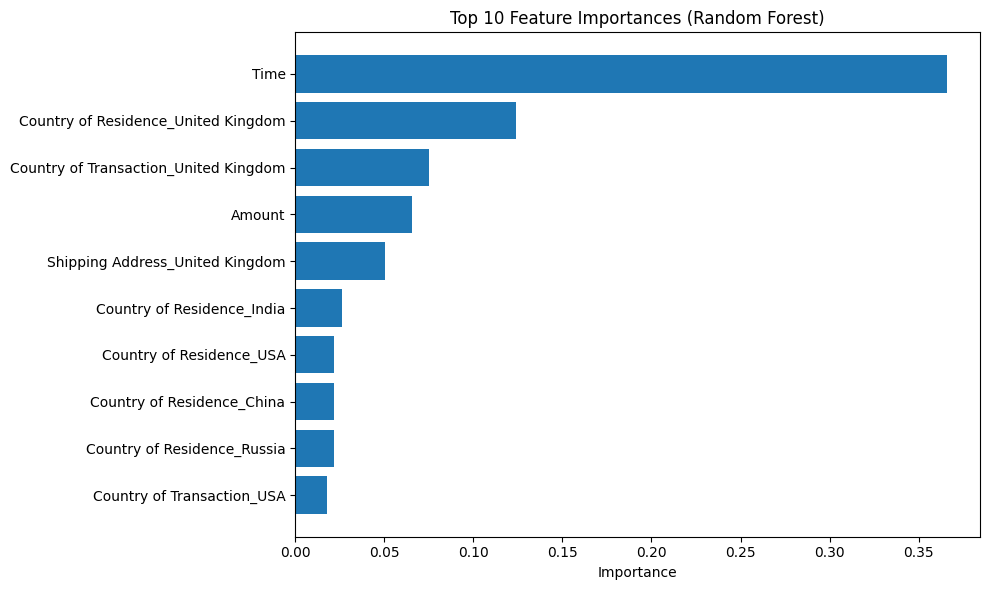


Most important feature: Time


In [7]:
# Question 7: Feature importance
# Extract feature importances from the random forest
feature_names_num = numeric_cols
feature_names_cat = rf_pipe.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_cols).tolist()
all_features = feature_names_num + feature_names_cat

importances = rf_pipe.named_steps['classifier'].feature_importances_

# Create DataFrame and sort
feat_imp = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Display top 10
print("Top 10 Most Important Features:")
display(feat_imp.head(10))

# Bar plot of top 10 feature importances
top10 = feat_imp.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10['Feature'][::-1], top10['Importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

print(f"\nMost important feature: {feat_imp.iloc[0]['Feature']}")

# Part 5: AdaBoost

In this section, you'll build an AdaBoost classifier.

## Question 8: AdaBoost Classifier

Build an AdaBoost classifier:
1. Create a pipeline with preprocessing and AdaBoostClassifier
2. Use DecisionTreeClassifier as base estimator with `max_depth=1` (decision stumps)
3. Set `n_estimators=100`, `learning_rate=1.0`, and `random_state=27`
4. Fit the model on training data
5. Make predictions on test set
6. Calculate and display:
   - Test accuracy
   - Test log loss

**Checkpoint Question**: What is the test accuracy? Round your answer to 4 decimal places.

In [8]:
# Question 8: AdaBoost classifier
from sklearn.ensemble import AdaBoostClassifier

# Create pipeline with preprocessing and AdaBoostClassifier
ada_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        learning_rate=1.0,
        random_state=27
    ))
])

# Fit the model
ada_pipe.fit(X_train, y_train)

# Make predictions
ada_pred = ada_pipe.predict(X_test)
ada_prob = ada_pipe.predict_proba(X_test)

# Calculate metrics
ada_acc = accuracy_score(y_test, ada_pred)
ada_ll = log_loss(y_test, ada_prob)

print(f"AdaBoost Test Accuracy: {ada_acc:.4f}")
print(f"AdaBoost Test Log Loss: {ada_ll:.4f}")

AdaBoost Test Accuracy: 0.9845
AdaBoost Test Log Loss: 0.4192


# Part 6: Gradient Boosting

In this section, you'll build a gradient boosting classifier.

## Question 9: Gradient Boosting Classifier

Build a gradient boosting classifier:
1. Create a pipeline with preprocessing and GradientBoostingClassifier
2. Use `n_estimators=100`, `learning_rate=0.1`, `max_depth=3`, and `random_state=27`
3. Fit the model on training data
4. Make predictions on test set
5. Calculate and display:
   - Test accuracy
   - Test log loss

**Checkpoint Question**: What is the test log loss? Round your answer to 4 decimal places.

In [9]:
# Question 9: Gradient boosting classifier
from sklearn.ensemble import GradientBoostingClassifier

# Create pipeline with preprocessing and GradientBoostingClassifier
gb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=27
    ))
])

# Fit the model
gb_pipe.fit(X_train, y_train)

# Make predictions
gb_pred = gb_pipe.predict(X_test)
gb_prob = gb_pipe.predict_proba(X_test)

# Calculate metrics
gb_acc = accuracy_score(y_test, gb_pred)
gb_ll = log_loss(y_test, gb_prob)

print(f"Gradient Boosting Test Accuracy: {gb_acc:.4f}")
print(f"Gradient Boosting Test Log Loss: {gb_ll:.4f}")

Gradient Boosting Test Accuracy: 0.9846
Gradient Boosting Test Log Loss: 0.0467


# Part 7: XGBoost

In this section, you'll build an XGBoost classifier if it's available.

## Question 10: XGBoost Classifier

Build an XGBoost classifier:
1. Import XGBClassifier from xgboost
2. Create a pipeline with preprocessing and XGBClassifier
3. Use `n_estimators=100`, `learning_rate=0.1`, `max_depth=3`, and `random_state=27`
4. Fit the model on training data
5. Make predictions on test set
6. Calculate and display:
   - Test accuracy
   - Test log loss

**Checkpoint Question**: What is the test accuracy? (Round to 4 decimal places)

In [10]:
# Question 10: XGBoost classifier
try:
    from xgboost import XGBClassifier
    
    # Create pipeline with preprocessing and XGBClassifier
    xgb_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=27,
            eval_metric='logloss'
        ))
    ])
    
    # Fit the model
    xgb_pipe.fit(X_train, y_train)
    
    # Make predictions
    xgb_pred = xgb_pipe.predict(X_test)
    xgb_prob = xgb_pipe.predict_proba(X_test)
    
    # Calculate metrics
    xgb_acc = accuracy_score(y_test, xgb_pred)
    xgb_ll = log_loss(y_test, xgb_prob)
    
    print(f"XGBoost Test Accuracy: {xgb_acc:.4f}")
    print(f"XGBoost Test Log Loss: {xgb_ll:.4f}")
    xgb_available = True
    
except ImportError:
    print("XGBoost is not installed. Skipping this model.")
    xgb_available = False

XGBoost is not installed. Skipping this model.


# Part 8: Stacking

In this section, you'll build a stacking classifier.

## Question 11: Stacking Classifier

Build a stacking classifier using the efficient pattern from Chapter 14:
1. Create a pipeline that includes:
   - The preprocessing step (same preprocessor used throughout)
   - A StackingClassifier with these base learners (no separate preprocessing needed):
     - LogisticRegression (max_iter=2000, random_state=27)
     - RandomForestClassifier (n_estimators=50, random_state=27)
     - KNeighborsClassifier (n_neighbors=15)
   - Final estimator: LogisticRegression()
   - Use `cv=5` for cross-validation and `n_jobs=-1`
2. Fit the model on training data
3. Make predictions on test set
4. Calculate and display:
   - Test accuracy
   - Test log loss

**Checkpoint Question**: What is the test log loss? Round your answer to 4 decimal places.

In [11]:
# Question 11: Stacking classifier
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Create pipeline with preprocessing and StackingClassifier
stack_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=2000, random_state=27)),
            ('rf', RandomForestClassifier(n_estimators=50, random_state=27)),
            ('knn', KNeighborsClassifier(n_neighbors=15))
        ],
        final_estimator=LogisticRegression(),
        cv=5,
        n_jobs=-1
    ))
])

# Fit the model
stack_pipe.fit(X_train, y_train)

# Make predictions
stack_pred = stack_pipe.predict(X_test)
stack_prob = stack_pipe.predict_proba(X_test)

# Calculate metrics
stack_acc = accuracy_score(y_test, stack_pred)
stack_ll = log_loss(y_test, stack_prob)

print(f"Stacking Test Accuracy: {stack_acc:.4f}")
print(f"Stacking Test Log Loss: {stack_ll:.4f}")

Stacking Test Accuracy: 0.9842
Stacking Test Log Loss: 0.0537


# Part 9: Model Comparison

In this section, you'll compare all models and analyze their performance.

## Question 12: Create Comparison Table

Create a comprehensive comparison of all models:
1. Create a list/dictionary to store results for all models:
   - Decision Tree (baseline)
   - Logistic Regression (baseline)
   - Bagging
   - Random Forest
   - AdaBoost
   - Gradient Boosting
   - XGBoost (if available)
   - Stacking
2. For each model, extract:
   - Model name
   - Test accuracy
   - Test log loss
3. Create a DataFrame with columns: Model Name, Test Accuracy, Test Log Loss
4. Sort by log loss (ascending), then by accuracy (descending)
5. Display the formatted comparison table

**Checkpoint Question**: Which model has the lowest log loss? (Answer with the exact model name from your table which should match the model names provided above)

In [12]:
# Question 12: Create comparison table
results = [
    {'Model Name': 'Decision Tree', 'Test Accuracy': dt_acc, 'Test Log Loss': dt_ll},
    {'Model Name': 'Logistic Regression', 'Test Accuracy': lr_acc, 'Test Log Loss': lr_ll},
    {'Model Name': 'Bagging', 'Test Accuracy': bag_acc, 'Test Log Loss': bag_ll},
    {'Model Name': 'Random Forest', 'Test Accuracy': rf_acc, 'Test Log Loss': rf_ll},
    {'Model Name': 'AdaBoost', 'Test Accuracy': ada_acc, 'Test Log Loss': ada_ll},
    {'Model Name': 'Gradient Boosting', 'Test Accuracy': gb_acc, 'Test Log Loss': gb_ll},
    {'Model Name': 'Stacking', 'Test Accuracy': stack_acc, 'Test Log Loss': stack_ll},
]

if xgb_available:
    results.append({'Model Name': 'XGBoost', 'Test Accuracy': xgb_acc, 'Test Log Loss': xgb_ll})

# Create DataFrame and sort by log loss (ascending), then accuracy (descending)
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=['Test Log Loss', 'Test Accuracy'], ascending=[True, False])
results_df = results_df.reset_index(drop=True)

print("Model Comparison Table (sorted by Log Loss):")
display(results_df)

print(f"\nModel with lowest log loss: {results_df.iloc[0]['Model Name']}")

Model Comparison Table (sorted by Log Loss):


,Model Name,Test Accuracy,Test Log Loss
0,Gradient Boosting,0.98460,0.046738
1,Random Forest,0.98500,0.052548
2,Stacking,0.98425,0.053743
3,Logistic Regression,0.97170,0.076756
4,Bagging,0.96315,0.078626
5,Decision Tree,0.96315,0.078724
6,AdaBoost,0.98450,0.419206



Model with lowest log loss: Gradient Boosting


## Question 13: Confusion Matrix Comparison

Compare confusion matrices for the top 2 models:
1. Identify the top 2 models based on log loss (from Question 12)
2. For each of the top 2 models:
   - Generate predictions on test set
   - Create confusion matrix
   - Plot confusion matrix as a heatmap
   - Calculate and display precision and recall for the fraud class (Fraud=1)
3. Compare the precision and recall values

**Checkpoint Question**: For the best model (lowest log loss), what is the recall for the fraud class (Fraud=1)? Round your answer to 4 decimal places.

Top 2 models by log loss: ['Gradient Boosting', 'Random Forest']

Gradient Boosting:
  Precision (Fraud=1): 0.9463
  Recall (Fraud=1): 0.8332

Random Forest:
  Precision (Fraud=1): 0.9863
  Recall (Fraud=1): 0.8026


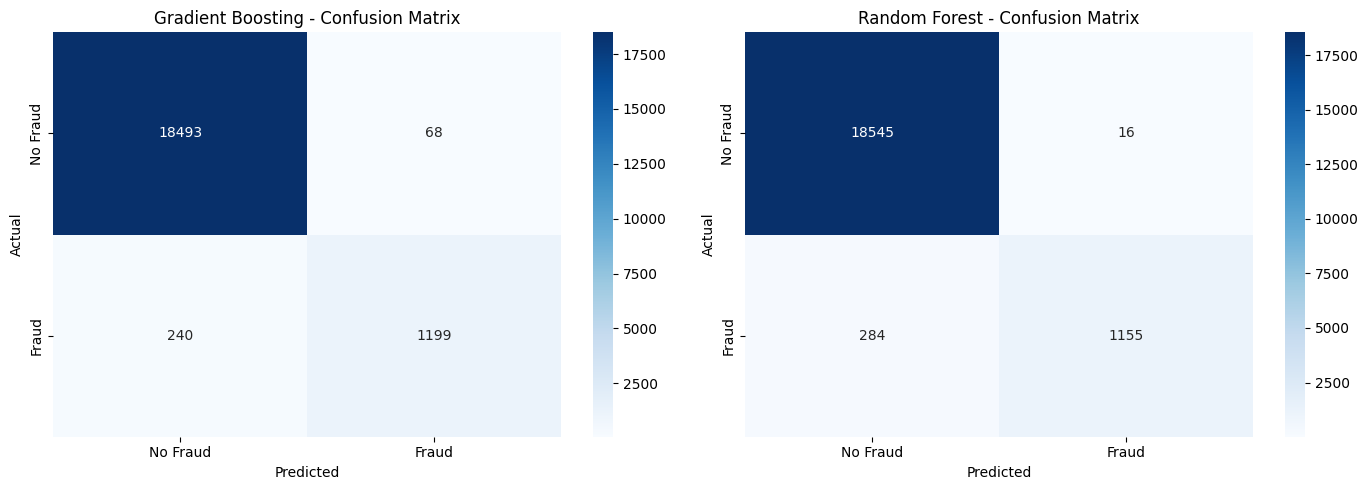


Best model (Gradient Boosting) Recall for Fraud=1: 0.8332


In [13]:
# Question 13: Confusion matrix comparison
from sklearn.metrics import precision_score, recall_score
import seaborn as sns

# Identify the top 2 models based on log loss
top2_names = results_df.head(2)['Model Name'].tolist()
print(f"Top 2 models by log loss: {top2_names}")

# Map model names to predictions
model_preds = {
    'Decision Tree': dt_pred,
    'Logistic Regression': lr_pred,
    'Bagging': bag_pred,
    'Random Forest': rf_pred,
    'AdaBoost': ada_pred,
    'Gradient Boosting': gb_pred,
    'Stacking': stack_pred,
}
if xgb_available:
    model_preds['XGBoost'] = xgb_pred

# Plot confusion matrices for top 2 models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, name in enumerate(top2_names):
    pred = model_preds[name]
    cm = confusion_matrix(y_test, pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
    axes[i].set_title(f'{name} - Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    print(f"\n{name}:")
    print(f"  Precision (Fraud=1): {prec:.4f}")
    print(f"  Recall (Fraud=1): {rec:.4f}")

plt.tight_layout()
plt.show()

# Best model recall
best_name = results_df.iloc[0]['Model Name']
best_recall = recall_score(y_test, model_preds[best_name])
print(f"\nBest model ({best_name}) Recall for Fraud=1: {best_recall:.4f}")

# Summary and Reflection

Congratulations! You've completed the coding portion of the Chapter 14 ensemble methods assessment. You've learned how to:

1. Prepare data for ensemble classification modeling
2. Build baseline models (decision tree, logistic regression)
3. Build bagging classifiers
4. Build random forest classifiers and interpret feature importance
5. Build boosting classifiers (AdaBoost, Gradient Boosting, XGBoost)
6. Build stacking classifiers
7. Compare ensemble methods to single models
8. Evaluate models using accuracy, log loss, and confusion matrices

**Important Reminders**:
- **Ensemble methods** combine multiple models to improve predictions
- **Bagging** reduces variance by averaging many models trained on bootstrap samples
- **Random Forests** add feature randomness to bagging for better decorrelation
- **Boosting** reduces both bias and variance by sequentially correcting errors
- **Stacking** uses a meta-learner to combine diverse base models
- **Log loss** measures probability quality, which is important for threshold-based decisions
- **Feature importance** helps identify which features drive predictions

---

